# Logistic Regression

In [121]:
import numpy as np 
import matplotlib.pyplot as plt
import sympy as sp
from IPython import display

In [122]:
m1, b = sp.symbols('m1 b')
variables = (m1, b)

# VISUALIZATION PARAMETERS
X_RANGE = (-10, 10)
Y_RANGE = (-10, 10)
Z_FIXED = 0
GRID_SIZE = 100

# LINEAR REGRESSION PARAMETERS
RANDOM_SEED = 42
N_SAMPLES = 10
NOISE = 10
INPUT_PARAMETERS = ([1, 2, 4, 5, 5.2, 5.6, 6, 7, 13, 13.1 ], [ 0, 0, 0, 0, 1, 1, 1, 1, 1, 1]) #np.random.randint(0, 1, N_SAMPLES) * 10)
INITIAL_POINT = [0.1, 0.0]
LEARNING_RATE = 2
GRADIENT_CLIPPING = True
CLIPPING_VAL = 50000.0
MAX_ITERATIONS = 1000

np.random.seed(RANDOM_SEED)

In [123]:
def dataset(n_samples=N_SAMPLES, noise=NOISE):
    """ 
    Generates a synthetic dataset for linear regression.

    INPUT ::
    n_samples: int, number of samples to generate
    noise: float, standard deviation of the Gaussian noise added to the target variable

    OUTPUT ::
    X: numpy array of shape (n_samples, 1), the input features
    Y: numpy array of shape (n_samples, 1), the input features
    z: numpy array of shape (n_samples, 1), the target variable
    
    """
    X = np.random.rand(n_samples) * 10 
    Y = np.random.rand(n_samples) * 10 # 3 * X + 4 * Y + np.random.randn(n_samples) * noise
    
    return X, Y

In [124]:
def sigmoid(z):
    """ 
    Sigmoid function

    INPUT ::
    z : numpy array or scalar, input to the sigmoid function

    OUTPUT ::
    sigmoid(z) : numpy array or scalar, output of the sigmoid function
    """
    
    return 1 / (1 + sp.exp(-z))

### Mesh Manager

In [125]:
def mesh_intialize(f, input_parameters=INPUT_PARAMETERS, x_range=X_RANGE, y_range=Y_RANGE, z_fixed=Z_FIXED, grid_size=GRID_SIZE):
    """ 
    Initializes the mesh grid for visualization

    INPUT ::
    f : sympy expression
    x_range : tuple ( min, max ) range for x-axis
    y_range : tuple ( min, max ) range for y-axis
    z_fixed : float value to fix z-axis for 2D contour plot
    grid_size : int number of points in the grid for both x and y axis

    OUTPUT ::
    fig : matplotlib figure object
    ax : matplotlib axes object
    dot : matplotlib line object for current position
    path : matplotlib line object for path taken by gradient descent
    """

    f_num = sp.lambdify(variables, f, 'numpy')


    list_x = np.linspace(x_range[0], x_range[1], grid_size)
    list_y = np.linspace(y_range[0], y_range[1], grid_size)
    X, Y = np.meshgrid(list_x, list_y)

    Z = np.zeros_like(X)
    Z = f_num(X, Y)

    data_x = input_parameters[0]
    data_y = input_parameters[1]

    fig = plt.figure(figsize=(12, 6))

    #Axe 1 for Linear Regression
    ax1 = fig.add_subplot(121)
    ax1.set_title(" Logistic Regression Fit ")
    ax1.set_xlabel("X")
    ax1.set_ylabel("Y")
    ax1.scatter(data_x, data_y, color='blue', label="Data Points")
    llhood_line, = ax1.plot([], [], 'r-', markersize=8, label="Linear Regression Line")
    ax1.legend()

    #Axe 2 for MSE
    ax2 = fig.add_subplot(122) # , projection="3D")
    ax2.set_title(" Gradient Descent Path on MSE Surface ")
    ax2.set_xlabel("m1")
    ax2.set_ylabel("b")
    ax2.legend()
    ax2.contour(X, Y, Z, levels=30, cmap='viridis', alpha=0.6)

    dot, = ax2.plot([], [], 'ro', markersize=8, label="Current Position")
    path, = ax2.plot([], [], 'r-', alpha=0.5, label="Path")
    marks = ax2.scatter([], [], c='blue', s=10, alpha=0.2)
        

    return fig, ax1, llhood_line, ax2, dot, path, marks

In [126]:
def mesh_update(llhood_line, dot, path, marks, history, new_point, x_range=X_RANGE, grid_size=GRID_SIZE):
    """ 
    Updates the visualization

    INPUT ::
    dot : matplotlib Line2D object representing the current position
    path : matplotlib Line2D object representing the path taken
    history : list of points representing the history of positions
    
    OUTPUT ::
    dot : updated Line2D object for current position
    path : updated Line2D object for path taken

    """

    list_x = np.linspace(x_range[0], x_range[1], grid_size)
    m1, b = new_point

    z_num = list_x * m1 + b
    y_pred = 1 / (1 + np.exp(-z_num)) # Utilisation de NumPy ici

    # Axe 1 update
    llhood_line.set_data(list_x, y_pred)
    
    # Axe 2 update
    h_array = np.array(history)

    dot.set_data([history[-1][0]], [history[-1][1]])
    path.set_data(h_array[:, 0], h_array[:, 1])
    marks.set_offsets(h_array[:, :2])

    return llhood_line

### Logistic Regression

In [127]:
def loss(input_parameters=INPUT_PARAMETERS, variables=variables):
    X, Y = input_parameters
    m1, b = variables
    n = len(X)
    
    total_loss = 0
    epsilon = 1e-10
    
    for i in range(n):
        # On calcule le Z pour ce point précis
        z = m1 * X[i] + b
        # On utilise sp.exp (SymPy) pour la dérivation
        prediction = 1 / (1 + sp.exp(-z))
        
        # Log-Loss pour un point
        point_loss = Y[i] * sp.log(prediction + epsilon) + (1 - Y[i]) * sp.log(1 - prediction + epsilon)
        total_loss += point_loss
        
    return -total_loss / n

In [128]:
def gradient(f, variables):
    """
    Computes the gradient vector of f with respect to the variables.

    INPUT ::
    f         : The function f as a sympy expression
    variables : Tuple of sympy symbols for the polynome

    OUTPUT ::
    gradient_vector : List of sympy expressions representing the gradient vector of f

    """
    gradient_vector = [sp.diff(f, var) for var in variables]

    return gradient_vector

In [129]:
def gradient_descent(f, variables, initial_point=INITIAL_POINT, learning_rate=LEARNING_RATE, gradient_clipping=GRADIENT_CLIPPING, clipping_val = CLIPPING_VAL, max_iterations=MAX_ITERATIONS):
    """ 
    Performs gradient descent optimization on the function f.

    INPUT ::
    f                 : The function f as a sympy expression
    variables         : Tuple of sympy symbols for the polynome
    initial_point     : List of values for starting point of the optimization
    learning_rate     : Step size for each iteration of gradient descent
    gradient_clipping : Boolean to indicate whether to apply gradient clipping
    clipping_val      : Value to clip the gradients if gradient_clipping is True
    max_iterations    : Maximum number of iterations for the optimization

    OUTPUT ::
    point             : Final point after performing gradient descent optimization
    
    """
    point = np.array(initial_point, dtype=np.float64)
    grad = gradient(f, variables)
    grad_func = sp.lambdify(variables, grad, 'numpy')
    fig, ax1, llhood_line, ax2, dot, path, marks = mesh_intialize(loss(INPUT_PARAMETERS, variables))
    history = [point.copy()]

    plt.show()

    for i in range(max_iterations):
        grad_eval = grad_func(*point)

        if gradient_clipping:
            grad_eval = np.clip(grad_eval, -clipping_val, clipping_val)

        point -= learning_rate * grad_eval

        history.append(point.copy())

        if i % 50 == 0:
            mesh_update(llhood_line, dot, path, marks, history, point)
            display.clear_output(wait=True)
            display.display(fig)
            plt.pause(0.5)

    return point

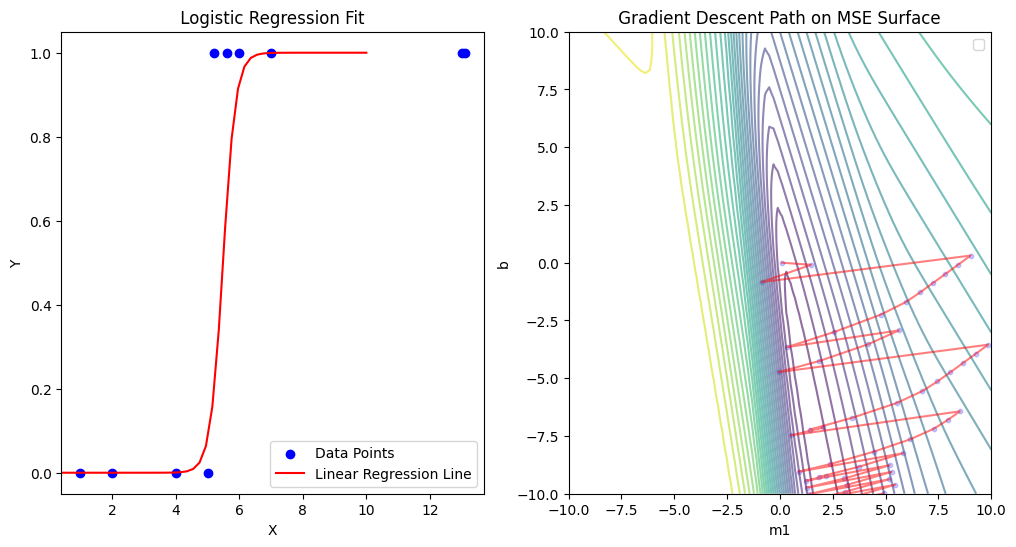

Final Point (m1, b): [  6.31249413 -27.61989738]


In [130]:

final_point = gradient_descent(loss(INPUT_PARAMETERS, variables), variables)

print(f"Final Point (m1, b): {final_point}")